# The run: actor-critic PPO on Qwen3-1.7B

[`01_actor_critic_and_gae.ipynb`](01_actor_critic_and_gae.ipynb) checked the mathematics
without a GPU. This one spends one. Same frozen data, same deterministic reward, same model
and the same clipped surrogate as
[`../../membrane_grpo/grpo_scratch.py`](../../membrane_grpo/grpo_scratch.py) — the baseline
is a learned $V_\phi(s_t)$ instead of a group mean, and the advantage is per token instead
of per sequence.

**Scale: this is a smoke test.** A short run on one card, not a converged training run.
Every claim below is scoped to that, exactly as `membrane_grpo`'s own README scopes its.

---

## Why this model, and why not the 0.5B any more

The model was chosen on the GRPO side by measurement rather than by argument
(`membrane_grpo/runs/sel-*`, three candidates on one ruler), and the two reasons that
decided it both apply here unchanged:

| frozen, dev, greedy | Qwen2.5-0.5B | **Qwen3-1.7B** |
| --- | --- | --- |
| schema valid | 0.005 | **0.970** |
| `cause_acc` | 0.145 | **0.255** |
| chance rate for `cause_acc` | 0.143 | 0.143 |
| `numeric_acc` | 0.000 | 0.038 |

The 0.5B's headline result was **confounded**: 52% of its reward gain was schema validity
going $0.005 \to 1.000$, which is formatting, not diagnosis. Here that headroom is worth at
most $0.003$, so a reward rise on this model cannot be explained away as format learning.
And its `cause_acc` sat *exactly* at the $1/7$ chance rate, leaving RL nothing partial to
sharpen; this one starts a real distance above it.

---

## Before running: the card has to be free

`anton` has a single RTX 5070 Ti, 16 GiB, and the vLLM 9B service normally holds ~14.6 GiB
of it. Nothing here will fit alongside it. Stopping the stack needs `sudo`, there is no
`NOPASSWD` rule on this machine, and `deploy/stack.sh` says so in its own header — so it is
**run by a person at a terminal, not by this notebook and not by an agent**:

```sh
deploy/stack.sh down                       # if you are on a branch that has it
sudo systemctl stop vllm-qwen membraneclaw-agent   # equivalent, any branch
```

and afterwards:

```sh
deploy/stack.sh up
```

The next cell refuses to continue rather than letting a run OOM twenty minutes in.

In [1]:
import sys, json, subprocess
from pathlib import Path

HERE = Path.cwd() if (Path.cwd() / "ppo_ac.py").exists() else Path("experiments/notebooks/smoke_test")
sys.path.insert(0, str(HERE.resolve()))

import torch
import ppo_ac
from ppo_ac import Config, train, resolve_device

# 11 GiB, not the 0.5B run's 8: Qwen3-1.7B is 3.4 GiB of bf16 weights before
# any activation, and the value head forces `output_hidden_states=True`, which
# keeps all 29 layers' hidden states alive through the backward pass.
MIN_FREE_MIB = 11000
BLOCKING_UNITS = ["vllm-qwen", "membraneclaw-agent"]

assert torch.cuda.is_available(), "no CUDA device; this notebook is the GPU half of the pair"
name = torch.cuda.get_device_name(0)

# Two sources, because on this machine they disagree and only one of them is right.
# `torch.cuda.mem_get_info` reported 13454 MiB free while nvidia-smi reported 544 --
# under WSL2 the CUDA driver counts memory it could page to host RAM as available to a
# new context. Trusting it starts a run that either crawls or dies twenty minutes in.
# nvidia-smi's number is the one that matches the card.
smi = subprocess.run(
    ["nvidia-smi", "--query-gpu=memory.used,memory.total", "--format=csv,noheader,nounits"],
    capture_output=True, text=True,
)
used, total = (int(x) for x in smi.stdout.strip().split(", "))
torch_free = torch.cuda.mem_get_info()[0] // 2**20
free = total - used

print(f"{name}: {free} / {total} MiB free per nvidia-smi   (torch claims {torch_free}; "
      f"see the comment above for why they differ)")

busy = {u: subprocess.run(["systemctl", "is-active", u], capture_output=True, text=True).stdout.strip()
        for u in BLOCKING_UNITS}
running = [u for u, s in busy.items() if s == "active"]

if free < MIN_FREE_MIB or running:
    raise RuntimeError(
        f"the card is not free: {free} MiB available (need ~{MIN_FREE_MIB}), "
        f"still running {running or 'nothing'}.\n"
        f"From a terminal (needs sudo, no NOPASSWD rule here -- not from this notebook):\n"
        f"    sudo systemctl stop {' '.join(BLOCKING_UNITS)}\n"
        f"and afterwards:  sudo systemctl start {' '.join(BLOCKING_UNITS)}"
    )
print("card is free; the run may proceed")

NVIDIA GeForce RTX 5070 Ti: 15105 / 16303 MiB free per nvidia-smi   (torch claims 15009; see the comment above for why they differ)
card is free; the run may proceed


## The configuration, and why it is what it is

A step is 8 prompts × 1 sample = **8 sequences**. One sample per prompt is the point: the
algorithm does not need a second sample of the same prompt to form a baseline, because the
baseline is a learned function rather than a group mean.

Three settings changed with the model, and none of them by taste:

* **`value_lr` 5e-6 → 8.5e-6.** $|\Delta V| \approx \text{lr}\cdot\lVert h\rVert_1$, and
  `01` measures $\lVert h \rVert_1$ at **4323** on the 0.5B and **2308** here. More
  dimensions, far smaller activations. Porting the old value unchanged would have cut the
  critic's step in half on the model where the critic was already the slowest thing in the
  loop.
* **`value_init_bias` is looked up, not typed.** `ppo_ac.FROZEN_BASELINE` holds one number
  per `(model, weight set)` pair, because the reward is a weighted sum: this same frozen
  policy scores $0.3015$ under `MAIN`, $0.4500$ under `PROBE`, $0.2615$ under `ABLATE`.
* **`micro_batch` 2 → 1.** Qwen3-1.7B is 3.4 GiB of bf16 weights before any activation, and
  the value head forces `output_hidden_states=True`, which keeps all 29 layers' hidden
  states alive through the backward pass.

`eval_every=25` is new. It is not decoration: this method has already produced a run
(`runs/gonogo-stage-s0`) whose *training* reward sat at $1.0000$ for thirty steps while the
policy it was checkpointing was worth $0.000$ on dev. A reward curve alone cannot tell
learning from collapse.

In [2]:
cfg = Config(
    # model, steps, value_lr, micro_batch and value_init_bias all come from the
    # dataclass defaults now -- see ppo_ac.Config, where each is argued for.
    prompts_per_step=8,
    samples_per_prompt=1,     # the point: no group needed
    max_new_tokens=640,
    temperature=1.0,
    lr=1e-5,
    lam=1.0,                  # A_t = R - V(s_t); the honest default
    gamma=1.0,
    clip_eps=0.2,
    value_clip_eps=0.2,
    value_coef=0.5,
    value_detach=True,        # the critic is a probe, not a co-author of the trunk
    whiten_advantages=False,  # see 01: whitening would hide whether the critic works
    inner_epochs=1,           # at rho=1 the clip is inert by construction
    lora_r=16,
    weights="MAIN",
    seed=0,
    dtype="bfloat16",
    split="train",
)
tag = cfg.model.rsplit("/", 1)[-1].replace(".", "").lower()
OUT = HERE / "runs" / f"ppo-{tag}-{cfg.weights.lower()}-s{cfg.seed}"
print(json.dumps({k: v for k, v in cfg.__dict__.items() if k != "metrics"}, indent=2))
print(f"\nvalue head starts at {cfg.value_init_bias} "
      f"= frozen {cfg.model} on dev under {cfg.weights}")

{
  "model": "Qwen/Qwen3-1.7B",
  "steps": 200,
  "prompts_per_step": 8,
  "samples_per_prompt": 1,
  "max_new_tokens": 640,
  "temperature": 1.0,
  "lr": 1e-05,
  "value_lr": 3e-05,
  "weight_decay": 0.0,
  "gamma": 1.0,
  "lam": 1.0,
  "clip_eps": 0.2,
  "value_clip_eps": 0.2,
  "value_coef": 0.5,
  "value_detach": true,
  "normalize_value": false,
  "critic_epochs": 8,
  "whiten_advantages": false,
  "value_init_bias": 0.3015,
  "inner_epochs": 1,
  "micro_batch": 1,
  "normalize": "token",
  "lora_r": 16,
  "weights": "MAIN",
  "seed": 0,
  "dtype": "bfloat16",
  "split": "train",
  "prompt_version": "v2",
  "eval_every": 25,
  "eval_cases": 200,
  "eval_batch": 32,
  "eval_split": "dev",
  "eval_max_tokens": 640
}

value head starts at 0.3015 = frozen Qwen/Qwen3-1.7B on dev under MAIN


In [3]:
# Guarded so re-executing this notebook against a finished run plots it rather than
# spending another 35 minutes reproducing it. Delete the directory to force a rerun.
if (OUT / "metrics.jsonl").exists():
    history = None
    print(f"{OUT} already exists -- skipping training, plotting the stored run.")
    print("   delete the directory to train again.")
else:
    history = train(cfg, OUT, resolve_device("auto"))
    print(f"\n{len(history)} steps -> {OUT}")

/home/bayan/MembraneClaw/experiments/notebooks/smoke_test/runs/ppo-qwen3-17b-main-s0 already exists -- skipping training, plotting the stored run.
   delete the directory to train again.


## Curves — all runs on one figure

Six panels, every run overlaid, so the weight sets are read against each other rather than
against a memory of the previous plot. Each run also gets its own `curves.png` written into
its directory, but the merged figure is the one to look at.

Two panels differ from the obvious choice, and both times because the obvious one is dead
here. `unique_completions` is the batch size on every step (`samples_per_prompt=1`), so it
carries nothing; `clip_frac` takes its slot, because whether the trust region engages at all
is the open question about this configuration. And the held-out panel shows `cause_acc`
alone rather than four component curves — three runs times four metrics is twelve lines,
and `cause_acc` is the one that is weight-independent and that the experiment is about.

**The reward panel is the one to read carefully.** The three weight sets are different
weighted sums, so their rewards are denominated in different units: the same frozen policy
scores 0.3015 under `MAIN`, 0.4500 under `PROBE` and 0.2615 under `ABLATE`. Each run's own
frozen line is drawn in its own colour, so a curve is only ever compared to its own start.
The accuracy panels carry across between runs; the reward panel does not.

MAIN    cause_acc  step 0 0.235  ->  step 200 0.170   (peak 0.255 at step 50)
ABLATE  cause_acc  step 0 0.235  ->  step 200 0.245   (peak 0.260 at step 100)
PROBE   cause_acc  step 0 0.235  ->  step 200 0.335   (peak 0.380 at step 150)


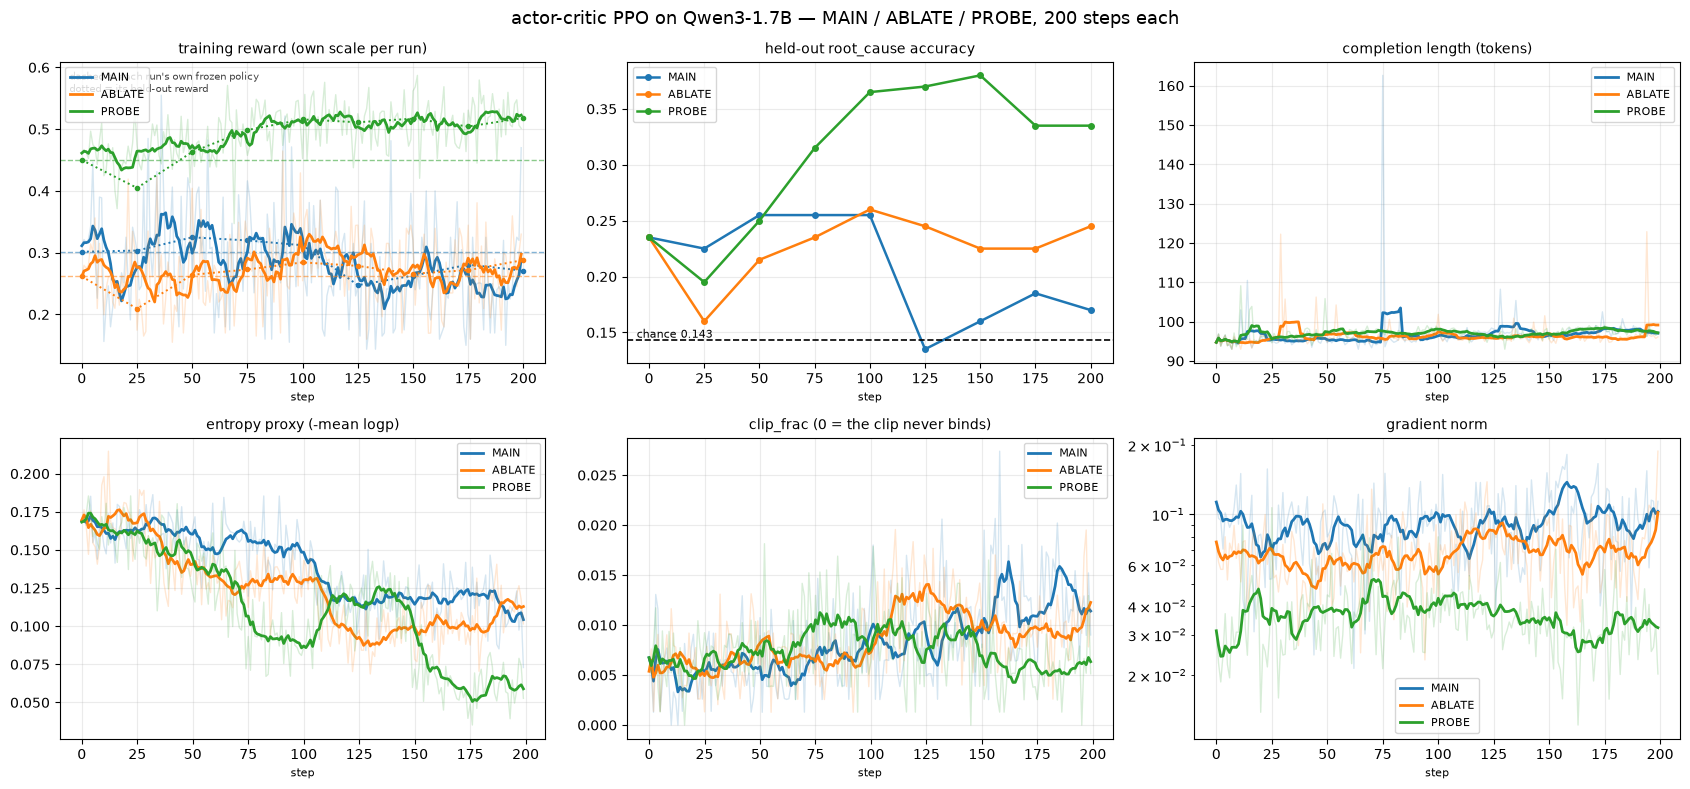

In [4]:
import matplotlib.pyplot as plt


def load_jsonl(path):
    path = Path(path)
    if not path.exists():
        return []
    return [json.loads(l) for l in path.read_text().splitlines() if l.strip()]


def smooth(values, window=9):
    return [
        sum(values[max(0, i - window + 1) : i + 1]) / len(values[max(0, i - window + 1) : i + 1])
        for i in range(len(values))
    ]


ALL_RUNS = {
    "MAIN":   HERE / "runs" / "ppo-qwen3-17b-main-s0",
    "ABLATE": HERE / "runs" / "ppo-qwen3-17b-ablate-s0",
    "PROBE":  HERE / "runs" / "ppo-qwen3-17b-probe-s0",
}
RUNS = {k: v for k, v in ALL_RUNS.items() if (v / "metrics.jsonl").exists()}
if len(RUNS) < len(ALL_RUNS):
    print(f"not run yet, skipped: {', '.join(k for k in ALL_RUNS if k not in RUNS)}\n")

DATA = {name: (load_jsonl(run / "metrics.jsonl"), load_jsonl(run / "eval.jsonl"),
               json.loads((run / "config.json").read_text()))
        for name, run in RUNS.items()}
COLOUR = {name: f"C{i}" for i, name in enumerate(ALL_RUNS)}
CONSTANT_GUESS, SKIP_CORRECTION = 0.245, 0.890
CHANCE_CAUSE = 1 / 7

# (metric, title, log scale, whether it comes from eval.jsonl)
PANELS = (
    ("reward_mean",       "training reward (own scale per run)", False, False),
    ("cause_acc",         "held-out root_cause accuracy",        False, True),
    ("completion_tokens", "completion length (tokens)",          False, False),
    ("entropy_proxy",     "entropy proxy (-mean logp)",          False, False),
    # Not `unique_completions`: with samples_per_prompt=1 that is the batch size on
    # every step. Whether the trust region ever engages is the live question.
    ("clip_frac",         "clip_frac (0 = the clip never binds)", False, False),
    ("grad_norm",         "gradient norm",                        True,  False),
)

fig, axes = plt.subplots(2, 3, figsize=(17, 8))
for ax, (key, title, log, from_eval) in zip(axes.flat, PANELS):
    for name, (rows, evals, cfg_run) in DATA.items():
        c = COLOUR[name]
        if from_eval:
            ax.plot([e["step"] for e in evals], [e[key] for e in evals],
                    marker="o", markersize=4, linewidth=1.8, color=c, label=name)
        else:
            steps = [r["step"] for r in rows]
            values = [float(r[key]) for r in rows]
            ax.plot(steps, values, alpha=0.18, linewidth=1, color=c)
            ax.plot(steps, smooth(values), linewidth=2, color=c, label=name)
        if key == "reward_mean":
            frozen = ppo_ac.value_init_bias_for(cfg_run["model"], cfg_run["weights"])
            ax.axhline(frozen, linestyle="--", linewidth=1, color=c, alpha=0.55)
            ax.plot([e["step"] for e in evals], [e["reward"] for e in evals],
                    marker="o", markersize=3, linestyle=":", linewidth=1.4, color=c)

    if key == "cause_acc":
        ax.axhline(CHANCE_CAUSE, linestyle="--", linewidth=1.2, color="k")
        ax.annotate(f"chance {CHANCE_CAUSE:.3f}", xy=(0.02, CHANCE_CAUSE),
                    xycoords=("axes fraction", "data"), fontsize=8, va="bottom")
    if key == "reward_mean":
        ax.annotate("dashed = each run's own frozen policy\ndotted = its held-out reward",
                    xy=(0.02, 0.97), xycoords="axes fraction", fontsize=7,
                    va="top", alpha=0.75)
    if log:
        ax.set_yscale("log")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("step", fontsize=8)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

fig.suptitle("actor-critic PPO on Qwen3-1.7B — MAIN / ABLATE / PROBE, 200 steps each",
             fontsize=13)
fig.tight_layout()
fig.savefig(HERE / "runs" / "three_runs.png", dpi=140)

for name, (rows, evals, _) in DATA.items():
    first, last = evals[0], evals[-1]
    peak = max(evals, key=lambda e: e["cause_acc"])
    print(f"{name:<7} cause_acc  step 0 {first['cause_acc']:.3f}"
          f"  ->  step {last['step']} {last['cause_acc']:.3f}"
          f"   (peak {peak['cause_acc']:.3f} at step {peak['step']})")

## The critic, and the two things the first runs got wrong

Four panels, all runs overlaid.

* **`value_ev`** — out-of-sample: the head as it stood *before* this batch was fitted,
  scored on data it had not seen. Zero means it is doing exactly as well as predicting the
  mean of the returns, and it is the operative number, since those are the values GAE built
  the advantages from.
* **`value_ev_fit`** — in-sample, after `critic_epochs` steps on this same batch. It
  separates a head that cannot fit the batch at all from one that fits it and then fails to
  generalise to the next.
* **`value_std`** — the within-batch spread of $V$. Near zero means every token gets the
  same baseline, so $A_t = R - \text{const}$ and this is REINFORCE with a moving average.
* **`adv_std / |adv_mean|`** — how much of the advantage is per-token rather than a scalar
  broadcast to the whole sequence. This is the method's entire claim over GRPO. In the runs
  before the fixes it was **6.4%**.

run        value_ev    ev_fit  value_std  per-token  clip_frac    undef
MAIN        +0.0091   +0.0142     0.0422        46%     0.0077       28
ABLATE      -0.0030   +0.0148     0.0354        66%     0.0079       12
PROBE       -0.0256   -0.0014     0.0219        58%     0.0076        3


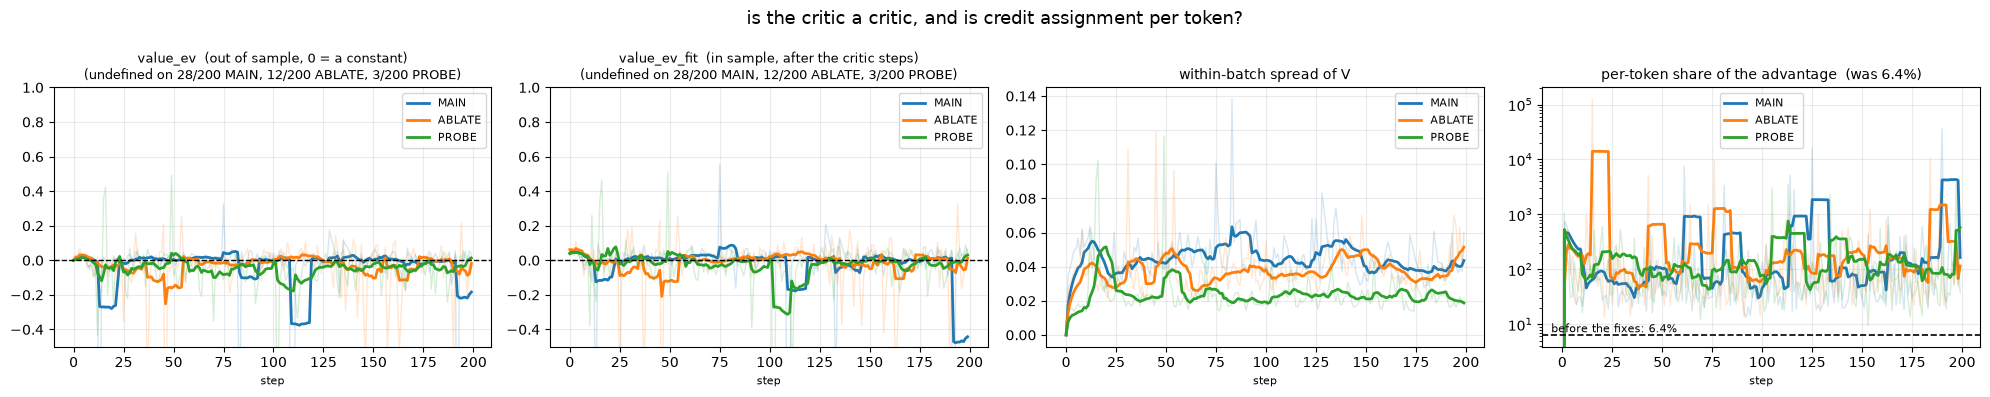

In [5]:
CRITIC_PANELS = (
    ("value_ev",  "value_ev  (out of sample, 0 = a constant)"),
    ("value_ev_fit", "value_ev_fit  (in sample, after the critic steps)"),
    ("value_std", "within-batch spread of V"),
    ("__pertoken__", "per-token share of the advantage  (was 6.4%)"),
)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (key, title) in zip(axes, CRITIC_PANELS):
    dropped = {}
    for name, (rows, _, _) in DATA.items():
        c = COLOUR[name]
        if key == "__pertoken__":
            pts = [(r["step"], 100 * r["adv_std"] / max(abs(r["adv_mean"]), 1e-9)) for r in rows]
        else:
            # Drop the steps where the metric is undefined, and drop them BEFORE
            # smoothing. set_ylim only pushes an outlier off the canvas; smooth()
            # is a moving average, so a single -1e13 drags the nine points around
            # it with it and the curve is drawn wrong rather than clipped. The
            # cause is a batch whose sequences all drew nearly the same reward,
            # so filter on that -- explained variance is bounded above by 1 but
            # unbounded below, and filtering on |EV| would throw away the real
            # cases where the critic is simply very wrong.
            pts = [(r["step"], float(r[key])) for r in rows
                   if r.get(key) is not None and r["reward_max"] - r["reward_mean"] >= 0.05]
        steps, values = [s for s, _ in pts], [v for _, v in pts]
        dropped[name] = len(rows) - len(pts)
        ax.plot(steps, values, alpha=0.18, linewidth=1, color=c)
        ax.plot(steps, smooth(values), linewidth=2, color=c, label=name)
    if key.startswith("value_ev"):
        ax.axhline(0.0, linestyle="--", linewidth=1, color="k")
        ax.set_ylim(-0.5, 1.0)
    if key == "__pertoken__":
        ax.axhline(6.4, linestyle="--", linewidth=1.2, color="k")
        ax.annotate("before the fixes: 6.4%", xy=(0.02, 6.4),
                    xycoords=("axes fraction", "data"), fontsize=8, va="bottom")
        ax.set_yscale("log")
    if key.startswith("value_ev") and any(dropped.values()):
        # Not a footnote: 15% of batches having no reward variance is a result.
        ax.set_title(f"{title}\n(undefined on "
                     + ", ".join(f"{v}/{len(DATA[k][0])} {k}" for k, v in dropped.items())
                     + ")", fontsize=9)
    else:
        ax.set_title(title, fontsize=10)
    ax.set_xlabel("step", fontsize=8)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

fig.suptitle("is the critic a critic, and is credit assignment per token?", fontsize=13)
fig.tight_layout()
fig.savefig(HERE / "runs" / "three_critic.png", dpi=140)

import numpy as np
print(f"{'run':<8}{'value_ev':>11}{'ev_fit':>10}{'value_std':>11}{'per-token':>11}{'clip_frac':>11}{'undef':>9}")
for name, (rows, _, _) in DATA.items():
    ok = [r for r in rows if r["reward_max"] - r["reward_mean"] >= 0.05]
    med = lambda k, src=rows: float(np.median([r[k] for r in src if r.get(k) is not None]))
    pt = float(np.median([r["adv_std"] / max(abs(r["adv_mean"]), 1e-9) for r in rows]))
    print(f"{name:<8}{med('value_ev', ok):>+11.4f}{med('value_ev_fit', ok):>+10.4f}"
          f"{med('value_std'):>11.4f}{pt * 100:>10.0f}%{med('clip_frac'):>11.4f}"
          f"{len(rows) - len(ok):>9d}")

## The three weight sets, component by component

The merged figure above carries `cause_acc`. These are the other three held-out components,
which say *where* a run put its effort.

| | `format` | `numeric` | `flags` | `stage` | `root_cause` | `action` |
| --- | --- | --- | --- | --- | --- | --- |
| `MAIN` | 0.10 | 0.15 | 0.12 | 0.03 | **0.45** | 0.15 |
| `PROBE` | **0.35** | **0.35** | 0.12 | 0.03 | 0.10 | 0.05 |
| `ABLATE` | 0.10 | **0.35** | 0.12 | 0.03 | 0.25 | 0.15 |

`PROBE` was built as a deliberately misspecified reward — it moves weight away from the
diagnosis and onto formatting and arithmetic. `ABLATE` isolates one variable out of it:
`numeric` at `PROBE`'s 0.35 while `root_cause` stays substantial at 0.25, with `format` and
`action` left at `MAIN`'s values. So `ABLATE` differs from `MAIN` in exactly two components,
a single 0.20 transferred from `root_cause` to `numeric`, and everything else is held.

The hypothesis under test is that the task is a chain — `numeric → flags → cause` — and
that weighting its head beats weighting its tail, because the tail is only reachable
through numbers the policy is getting wrong. Note that `PROBE`'s reward is inflated by
construction rather than by merit: it puts 0.35 on `format`, and this model's schema
validity starts at 0.965, so a third of its reward is collected before training begins.

            cause_acc  numeric_acc    flags_acc   action_acc    schema_ok
MAIN           0.2350       0.0350       0.3233       0.1750       0.9650   <- step 0
               0.1700       0.0200       0.3117       0.1600       1.0000   <- step 200
              -0.0650      -0.0150      -0.0117      -0.0150      +0.0350   <- delta

ABLATE         0.2350       0.0350       0.3233       0.1750       0.9650   <- step 0
               0.2450       0.0517       0.3983       0.2150       0.9900   <- step 200
              +0.0100      +0.0167      +0.0750      +0.0400      +0.0250   <- delta

PROBE          0.2350       0.0350       0.3233       0.1750       0.9650   <- step 0
               0.3350       0.0283       0.6767       0.2700       1.0000   <- step 200
              +0.1000      -0.0067      +0.3533      +0.0950      +0.0350   <- delta



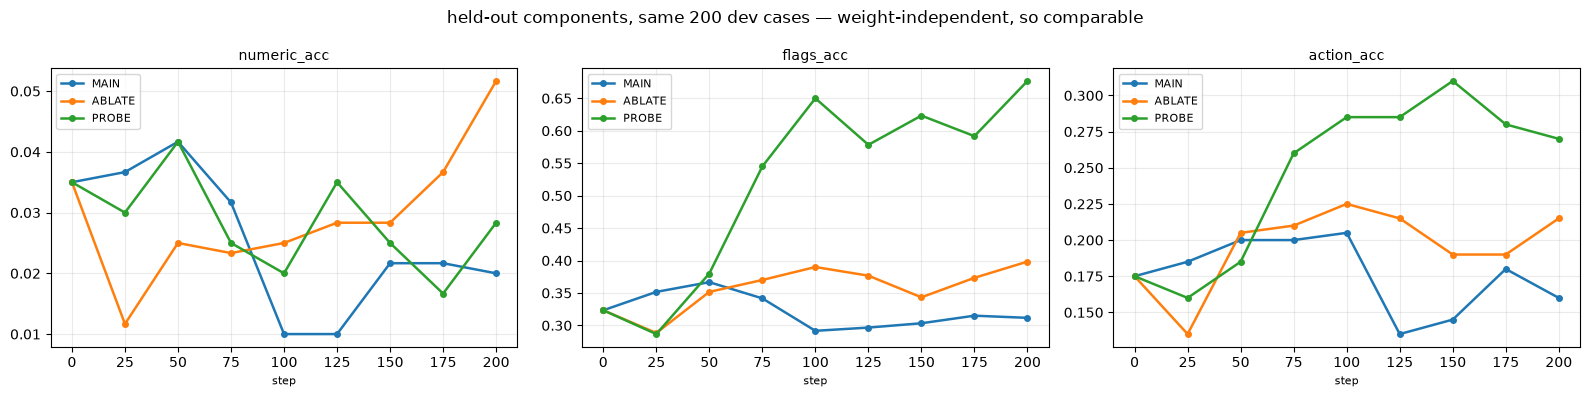

In [6]:
# The components the merged figure does not carry. cause_acc is up there; these say
# where each run actually spent itself.
COMPARABLE = ("numeric_acc", "flags_acc", "action_acc")
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric in zip(axes, COMPARABLE):
    for name, (_, evals, _) in DATA.items():
        ax.plot([e["step"] for e in evals], [e[metric] for e in evals],
                marker="o", markersize=4, linewidth=1.8, color=COLOUR[name], label=name)
    ax.set_title(metric, fontsize=10)
    ax.set_xlabel("step", fontsize=8)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
fig.suptitle("held-out components, same 200 dev cases — weight-independent, so comparable",
             fontsize=12)
fig.tight_layout()
fig.savefig(HERE / "runs" / "three_components.png", dpi=140)

width = max(len(n) for n in DATA) + 2
cols = ("cause_acc",) + COMPARABLE + ("schema_ok",)
print(f"{'':{width}}" + "".join(f"{m:>13}" for m in cols))
for name, (_, evals, _) in DATA.items():
    for label, e in (("step 0", evals[0]), (f"step {evals[-1]['step']}", evals[-1])):
        tag = name if label == "step 0" else ""
        print(f"{tag:{width}}" + "".join(f"{e[m]:>13.4f}" for m in cols) + f"   <- {label}")
    d = {m: evals[-1][m] - evals[0][m] for m in cols}
    print(f"{'':{width}}" + "".join(f"{d[m]:>+13.4f}" for m in cols) + "   <- delta\n")

## The paired test

Every `cause_acc` number above is quoted from aggregates, and aggregates force the wrong
comparison. The independent-sample standard error on a proportion near $0.26$ over 200
cases is $0.031$, so $+0.055$ is about 1.8 SE and $+0.050$ is less — neither survives that
test, and the two are well inside noise of each other.

But these are not independent samples. They are the **same 200 cases, in the same order,
decoded greedily**. Almost every case is answered identically by both policies, and those
cases carry no information about the difference. Only the disagreements do, and McNemar's
exact test uses exactly them. It is the test the design called for all along.

Three greedy evaluations are needed — the frozen policy, the `MAIN` adapter, the `ABLATE`
adapter — each through `eval.generate_hf` so the per-case outcomes come from the same code
path that produced everything else here. `eval.summarise` writes the `per_case` block that
`paired_test` requires.

The reward weights are irrelevant to this test and `MAIN` is used for all three envelopes:
`cause`, `exact` and `schema` are per-case booleans, and no weight vector can change whether
a given completion named the right root cause.

In [7]:
import hashlib
import torch
from eval import generate_hf, summarise

PAIRED = HERE / "runs" / "paired"
PAIRED.mkdir(parents=True, exist_ok=True)

DEV = ppo_ac.DATA / "dev.jsonl"
SPLIT_SHA = hashlib.sha256(DEV.read_bytes()).hexdigest()
dev_cases = [json.loads(l) for l in DEV.read_text().splitlines()][: cfg.eval_cases]

# The frozen policy plus every run that exists, so adding a weight set to ALL_RUNS is
# the only edit a third or fourth comparison needs.
POLICIES = {"base": None}
POLICIES.update({name.lower(): run / "adapter" for name, run in RUNS.items()})

for name, adapter in POLICIES.items():
    dest = PAIRED / f"{name}.json"
    if dest.exists():
        print(f"{dest.name} already written, skipping")
        continue
    results = generate_hf(
        dev_cases,
        model=cfg.model,
        device=resolve_device("auto"),
        dtype=cfg.dtype,
        n=1,
        temperature=0.0,                     # greedy: the policy is the only thing varying
        max_tokens=cfg.eval_max_tokens,
        seed=cfg.seed,
        batch_size=cfg.eval_batch,
        adapter=str(adapter) if adapter else None,
        prompt_version=cfg.prompt_version,
    )
    overall = summarise(results, ppo_ac.WEIGHT_SETS["MAIN"])
    # The same envelope eval.py writes, so paired_test.py reads these unmodified.
    dest.write_text(json.dumps({
        "model": cfg.model,
        "backend": "hf",
        "split": cfg.eval_split,
        "split_sha256": SPLIT_SHA,
        "prompt_version": cfg.prompt_version,
        "weights": "MAIN",
        "mode": "greedy",
        "k": 1,
        "temperature": 0.0,
        "max_tokens": cfg.eval_max_tokens,
        "seed": cfg.seed,
        "adapter": str(adapter) if adapter else None,
        "overall": overall,
    }, indent=2, default=str) + "\n")
    print(f"  {name:8s} reward {overall['reward']:.4f}  cause {overall['cause_acc']:.3f}"
          f"  -> {dest.name}")
    torch.cuda.empty_cache()

/home/bayan/MembraneClaw/experiments/membrane_grpo/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Loading weights:   4%|▍         | 12/311 [00:00<00:02, 106.71it/s]

Loading weights:   7%|▋         | 23/311 [00:00<00:02, 101.97it/s]

Loading weights:  11%|█         | 34/311 [00:00<00:03, 88.98it/s] 

...

Loading weights:  56%|█████▌    | 173/311 [00:00<00:00, 1724.87it/s]

Loading weights: 100%|██████████| 311/311 [00:00<00:00, 1958.08it/s]

  chat template honours enable_thinking; set to False


  probe    reward 0.4067  cause 0.335  -> probe.json


  200/200 cases


In [8]:
from paired_test import exact_binomial_two_sided


def per_case(name):
    payload = json.loads((PAIRED / f"{name}.json").read_text())
    if payload["split_sha256"] != SPLIT_SHA:
        raise SystemExit(f"{name} evaluated a different split; not comparable")
    return {r["id"]: r for r in payload["overall"]["per_case"]}


def mcnemar(before, after, metric="cause"):
    a, z = per_case(before), per_case(after)
    shared = sorted(set(a) & set(z))
    lost = [i for i in shared if a[i][metric] and not z[i][metric]]
    gained = [i for i in shared if not a[i][metric] and z[i][metric]]
    p = exact_binomial_two_sided(len(lost), len(gained))
    acc_a = sum(bool(a[i][metric]) for i in shared) / len(shared)
    acc_z = sum(bool(z[i][metric]) for i in shared) / len(shared)
    return {"n": len(shared), "before": acc_a, "after": acc_z,
            "lost": len(lost), "gained": len(gained),
            "discordant": len(lost) + len(gained), "p": p}


print("McNemar's exact test on `cause`, 200 paired dev cases, greedy\n")
head = f"  {'comparison':<22}{'before':>8}{'after':>8}{'gained':>8}{'lost':>7}{'discord':>9}{'p':>10}"
print(head)
print("  " + "-" * (len(head) - 2))
import itertools

trained = [n.lower() for n in RUNS]
comparisons = [("base", t, f"frozen -> {t.upper()}") for t in trained]
comparisons += [(x, y, f"{x.upper()} -> {y.upper()}") for x, y in itertools.combinations(trained, 2)]

for before, after, label in comparisons:
    r = mcnemar(before, after)
    print(f"  {label:<22}{r['before']:>8.3f}{r['after']:>8.3f}{r['gained']:>8d}"
          f"{r['lost']:>7d}{r['discordant']:>9d}{r['p']:>10.4f}")

print("\n  Only the discordant pairs carry information. A p above 0.05 means the split")
print("  between gained and lost is not distinguishable from a coin flip.")

McNemar's exact test on `cause`, 200 paired dev cases, greedy

  comparison              before   after  gained   lost  discord         p
  ------------------------------------------------------------------------
  frozen -> MAIN           0.235   0.170      32     45       77    0.1711
  frozen -> ABLATE         0.235   0.245      48     46       94    0.9179
  frozen -> PROBE          0.235   0.335      34     14       48    0.0055
  MAIN -> ABLATE           0.170   0.245      20      5       25    0.0041
  MAIN -> PROBE            0.170   0.335      60     27       87    0.0005
  ABLATE -> PROBE          0.245   0.335      61     43      104    0.0950

  Only the discordant pairs carry information. A p above 0.05 means the split
  between gained and lost is not distinguishable from a coin flip.


## The ablations worth running next

$\lambda$ is the one dial that decides what per-token credit assignment *means*.
`--lam 1.0` is $A_t = R - V(s_t)$, unbiased and noisy; `--lam 0.0` is pure bootstrapping off
the critic — which, given the critic panels above, is expected to be much worse here rather
than merely lower-variance. Same seed, same data, one flag:

```sh
V=../../membrane_grpo/.venv/bin/python
$V ppo_ac.py --lam 0.0             --out runs/ppo-qwen3-17b-lam0-s0
$V ppo_ac.py --whiten-advantages 1 --out runs/ppo-qwen3-17b-whitened-s0
$V ppo_ac.py --value-init-bias 0   --out runs/ppo-qwen3-17b-cold-critic-s0
```

The third is expected to fail in the specific way `01` predicts: a critic starting at zero
cannot produce a negative advantage against a non-negative reward, so the first updates
reinforce every completion including the worthless ones. If it does not fail that way, the
argument in `01` is wrong and should be corrected here. The failure should be *larger* than
it was on the 0.5B — the gap between a cold head and a calibrated one is 0.30 here against
0.086 before.

The third is the one to run next. `--lam 0.0` bootstraps entirely off the critic, and given
the panels above — explained variance at zero, $V$ effectively constant — it should be
markedly *worse* than $\lambda = 1$ rather than merely lower-variance. That is a falsifiable
prediction about a critic this file has already measured, which makes it worth a run.

## What this run does and does not show

**Does**: that the loop is correct end to end on real hardware at this scale, that a
learned baseline produces a usable gradient on every step, and — via the critic panels —
that the baseline is *not* a function of the state on this model either. `value_ev` sits at
zero for all 200 steps and the within-batch spread of $V$ is about 0.012 against a mean of
0.32, so what actually trained the policy was $R$ minus a slowly drifting scalar.

**Does not**: settle anything about which method is better, or about $\lambda$, or about the
critic's ceiling once it is allowed to move faster. It is one seed, one weight set, 200
steps, and a critic that was deliberately left at its ported learning rate so the model
change was the only variable.

The frozen baseline is the reminder of how far there is to go: `cause_acc` 0.255 against a
$1/7 = 0.143$ chance rate, `numeric_acc` 0.038, and exact match of exactly 0.000 — three
percent changes all inside 0.5 pp remains out of reach at this scale.

For a claim about `cause_acc` moving, aggregates are the wrong test: the two evaluations are
the *same* 200 cases, so run `membrane_grpo/eval.py` against `adapter/` and
`membrane_grpo/paired_test.py` over the two `per_case` blocks.